In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys

sys.path.append('../src')

from config.config import PATHS

from patterns.alternations import PatternGenerator
from graphs.graph_creator import StrategyGraphBuilder
from graphs.best_graph_creator import GraphCreator
from graphs.cycle_analyzer import CycleAnalyzer
from graphs.graph_display import GraphVisualizer
from analysis.simulation import load_graph_data, simulate

### Define parameters

In [2]:
N = 9
s = 3
seed = 42
Numpat = 10
permute_columns = True # permute agents
permute_rows = False # permute time
rng = np.random.default_rng(seed)

### Create random patterns and graphs

In [3]:
gen = PatternGenerator(
    N=N,
    step=s,
    num_patterns=Numpat,
    permute_columns=permute_columns,
    permute_rows=permute_rows,
    rng=rng
)

gen.generate_many()

pattern_file = PATHS['patterns'] / 'patterns.json'
gen.save(pattern_file)

gb = StrategyGraphBuilder(rng)

gb.build_graphs()

ca = CycleAnalyzer(
    num_nodes=N,
    num_steps=s,
)

ca.process()

[{'0a': {'pattern': ['0', '0', '1'], 'neigh': ['3a'], 'strat': {'0': '0', '1': '1'}, 'input freq': {'0': 2, '1': 1}}, '1a': {'pattern': ['1', '0', '0'], 'neigh': ['0a'], 'strat': {'0': '0', '1': '1'}, 'input freq': {'0': 2, '1': 1}}, '2a': {'pattern': ['1', '0', '0'], 'neigh': ['8a'], 'strat': {'0': '0', '1': '1'}, 'input freq': {'0': 2, '1': 1}}, '3a': {'pattern': ['0', '1', '0'], 'neigh': ['1a'], 'strat': {'1': '1', '0': '0'}, 'input freq': {'1': 1, '0': 2}}, '4a': {'pattern': ['0', '1', '0'], 'neigh': ['7a'], 'strat': {'1': '1', '0': '0'}, 'input freq': {'1': 1, '0': 2}}, '5a': {'pattern': ['0', '1', '0'], 'neigh': ['2a'], 'strat': {'1': '1', '0': '0'}, 'input freq': {'1': 1, '0': 2}}, '6a': {'pattern': ['0', '0', '1'], 'neigh': ['3a'], 'strat': {'0': '0', '1': '1'}, 'input freq': {'0': 2, '1': 1}}, '7a': {'pattern': ['1', '0', '0'], 'neigh': ['8a'], 'strat': {'0': '0', '1': '1'}, 'input freq': {'0': 2, '1': 1}}, '8a': {'pattern': ['0', '0', '1'], 'neigh': ['3a'], 'strat': {'0': '0'

### Create minumum diameter graph

In [4]:
graph = GraphCreator(N, s)
graph.build_graph()

output_path = graph.save_to_json()
print(f"Graph saved to: {output_path}")

ca = CycleAnalyzer(
    num_nodes=N,
    num_steps=s,
    sufix='_o'
)

ca.process()

Graph saved to: /home/carlos/Documents/InformationT/edgar_german/alternation_EFP/notebooks/../data/graphs/graph_data_N9s3_o.json
[{'0a': {'pattern': ['1', '0', '0'], 'neigh': ['6a'], 'strat': {'0': '0', '1': '1'}, 'input freq': {'0': 2, '1': 1}, 'cycle': 0, 'ones in cycle': 1}, '1a': {'pattern': ['1', '0', '0'], 'neigh': ['6a'], 'strat': {'0': '0', '1': '1'}, 'input freq': {'0': 2, '1': 1}, 'cycle': -1, 'ones in cycle': 0}, '2a': {'pattern': ['1', '0', '0'], 'neigh': ['6a'], 'strat': {'0': '0', '1': '1'}, 'input freq': {'0': 2, '1': 1}, 'cycle': -1, 'ones in cycle': 0}, '3a': {'pattern': ['0', '1', '0'], 'neigh': ['0a'], 'strat': {'0': '0', '1': '1'}, 'input freq': {'0': 2, '1': 1}, 'cycle': 0, 'ones in cycle': 1}, '4a': {'pattern': ['0', '1', '0'], 'neigh': ['0a'], 'strat': {'0': '0', '1': '1'}, 'input freq': {'0': 2, '1': 1}, 'cycle': -1, 'ones in cycle': 0}, '5a': {'pattern': ['0', '1', '0'], 'neigh': ['0a'], 'strat': {'0': '0', '1': '1'}, 'input freq': {'0': 2, '1': 1}, 'cycle': -1

### Plot graphs

In [5]:
# gv = GraphVisualizer(
#     num_nodes=N,
#     num_steps=s,
#     mode='pattern'
# )

# nets, output_files = gv.generate_all_patterns(width="600px", height="600px", physics=True)

# for i in range(len(nets)):
#     nets[i].show(str(output_files[i]), notebook=False)


# gv = GraphVisualizer(
#     num_nodes=N,
#     num_steps=s,
#     mode='pattern',
#     sufix='_o'
# )

# nets, output_files = gv.generate_all_patterns(width="600px", height="600px", physics=True)

# for i in range(len(nets)):
#     nets[i].show(str(output_files[i]), notebook=False)

# Simulations

In [6]:
# Compute the total payoff in a round for el farol bar problem, given N agents, B chairs and the current state
def compute_state_payoff(B, current_state):
    N = len(current_state)
    attendance = sum(1 for i in range(N) if current_state[i] == '1')
    if attendance <= B:
        return attendance  # All attendees get a payoff of 1
    else:
        return -attendance  # Only B attendees get a payoff of -1
    
# Find the period of the pattern
def find_pattern_period(series):
    first_p = series[-1]
    count = 1
    for p in range(len(series)-2, 0, -1):
        if series[p] != first_p:
            count += 1
        else:
            break
    return count

# Compute the inequality in a given pattern
def compute_inequality(series, i, T):
    window = series[i:i+T]
    t_window = np.array([list(s) for s in window]).T.astype(int)
    scores = np.sum(t_window, axis=1) / T
    return float(np.sqrt(scores.var()))


    #print(down_agents)
    

In [ ]:
procs = {i:1 for i in range(N)}
Neff = sum(procs.values())
steps = 50
agent_ids = [str(i) for i in procs.keys()]
#num_to_letter_map = dict(zip(range(0,26), string.ascii_lowercase))
#node_ids = [str(i)+num_to_letter_map[j] for i in procs.keys() for j in range(procs[i])]

for n in range(Numpat):
    series, ones = simulate(
        n=Neff, 
        s=s, 
        idx=n, 
        Nsteps=steps, 
        init_cond='0'*Neff,
        down_times=[0 for i in range(Neff)],
        down_lapses=[0 for i in range(Neff)], 
        down_agents=agent_ids, 
        random_thresh=0.5,
        seed=seed,
        sufix='_o',
        print_info=False
    )

In [8]:
T = find_pattern_period(series)
T

3

In [9]:
total_payoff = []
inequality = []
for i in range(0, len(series)-T):
    payoff = compute_state_payoff(s, series[i+T])
    ineq = compute_inequality(series, i, T)
    total_payoff.append(total_payoff[-1]+payoff if total_payoff else payoff)
    inequality.append(ineq)

Text(0.5, 1.0, 'Inequality Over Time')

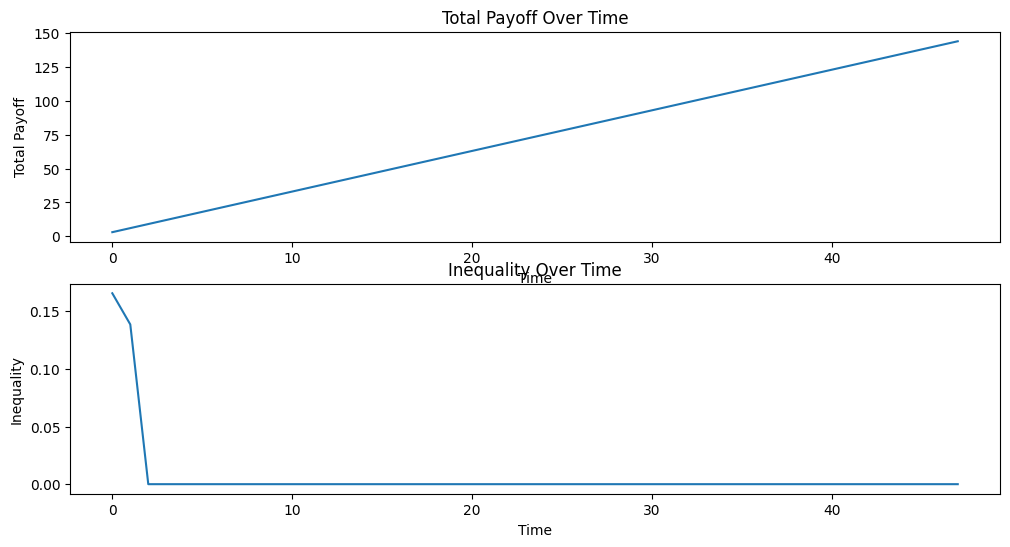

In [10]:
t = np.arange(len(total_payoff))
fig0 = plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(t, total_payoff, label='Total Payoff')
plt.xlabel('Time')
plt.ylabel('Total Payoff')
plt.title('Total Payoff Over Time')
plt.subplot(2, 1, 2)
plt.plot(t, inequality, label='Inequality')
plt.xlabel('Time')
plt.ylabel('Inequality')
plt.title('Inequality Over Time')